## 1. Imports and Configurations

In [113]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurations
LIG_THRESHOLD = 3  # Minimum number of ligands (both targets and off-targets) per protein

INPUT_KD_CSV = "/scratch/yunmin/data/graph/bdb/filtered/bindingdb_Kd_with_pdb_val_saved_pdb.csv"
INPUT_IC50_CSV = "/scratch/yunmin/data/graph/bdb/filtered/bindingdb_IC50_with_pdb_val_saved_pdb.csv"
CONCAT_CSV = "/scratch/yunmin/data/graph/bdb/filtered/bindingdb_concat_with_pdb_val_saved_pdb.csv"

OUT_DIR=f"/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_inputs/counts"
OUT_CSV=f"{OUT_DIR}/tar_pdb_off_count.csv"
INPUT_FILTERED_CSV = f"{OUT_DIR}/bindingdb_count_set{LIG_THRESHOLD}.csv"
OUT_FILTERED_CSV = f"{OUT_DIR}/tar_pdb_off_count_set{LIG_THRESHOLD}.csv"
PLOT_DIR = f"{OUT_DIR}/plots"

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

## 2. Load Data

In [114]:
df_kd = pd.read_csv(INPUT_KD_CSV)
df_ic50 = pd.read_csv(INPUT_IC50_CSV)

df_kd["assay_type"] = "Kd"
df_ic50["assay_type"] = "IC50"

df = pd.concat([df_kd, df_ic50], ignore_index=True)
df.to_csv(CONCAT_CSV, index=False)

print("===== # of rows =====")
kd_rows = len(df_kd)
ic50_rows = len(df_ic50)
combined_rows = len(df)
print(f"Kd: {len(df_kd)} ({kd_rows/combined_rows:.2%})")
print(f"IC50: {len(df_ic50)} ({ic50_rows/combined_rows:.2%})")
print(f"Combined: {len(df)}")

print("\n===== Columns in the combined dataframe =====")
print(df.columns)
df.head()


===== # of rows =====
Kd: 28033 (5.16%)
IC50: 515395 (94.84%)
Combined: 543428

===== Columns in the combined dataframe =====
Index(['protein_key', 'uniprot_id', 'target_name', 'target_source', 'sequence',
       'sequence_length', 'ligand_inchikey', 'ligand_smiles', 'ligand_name',
       'ligand_het_id', 'original_Kd_nM', 'representative_assay_nM',
       'target_type', 'curation_source', 'doi', 'complex_pdb_id',
       'valid_pdb_id', 'validation_status', 'assay_type', 'original_IC50_nM'],
      dtype='object')


,protein_key,uniprot_id,target_name,target_source,sequence,sequence_length,ligand_inchikey,ligand_smiles,ligand_name,ligand_het_id,original_Kd_nM,representative_assay_nM,target_type,curation_source,doi,complex_pdb_id,valid_pdb_id,validation_status,assay_type,original_IC50_nM
0,C7C422_Klebsiella pneumoniae,C7C422,Metallo-beta-lactamase type 2,Klebsiella pneumoniae,MELPNIMHPVAKLSTALAAALMLSGCMPGEIRPTIGQQMETGDQRF...,270,XPRDUGXOWVXZLL-UHFFFAOYSA-N,COc1cccc(c1)-c1ccc(NC(=O)C2=C(CCC2)C(O)=O)c(F)c1,2-{[2-fluoro-4-(3-methoxyphenyl)phenyl]carbamo...,D5H,3.4,3.400000e+00,target,ChEMBL,10.1016/j.ejmech.2023.115225,5Y1J,NaN,No UniProt match,Kd,NaN
1,C7C422_Klebsiella pneumoniae,C7C422,Metallo-beta-lactamase type 2,Klebsiella pneumoniae,MELPNIMHPVAKLSTALAAALMLSGCMPGEIRPTIGQQMETGDQRF...,270,RNAHYXBPBZSDMH-CABZIAIVSA-N,CC(C)C(=O)[C@H](C)[C@H](O)[C@@]1(C)[C@H](C(C)=...,CHEMBL5398242,NaN,11800,1.180000e+04,off_target,ChEMBL,10.1039/d3md00036b,NaN,NaN,No PDB IDs,Kd,NaN
2,C7C422_Klebsiella pneumoniae,C7C422,Metallo-beta-lactamase type 2,Klebsiella pneumoniae,MELPNIMHPVAKLSTALAAALMLSGCMPGEIRPTIGQQMETGDQRF...,270,FAKRSMQSSFJEIM-RQJHMYQMSA-N,C[C@H](CS)C(=O)N1CCC[C@H]1C(O)=O,(2S)-1-[(2S)-2-methyl-3-sulfanylpropanoyl]pyrr...,X8Z,435000,4.350000e+05,off_target,ChEMBL,10.1021/acs.jmedchem.3c00171,"4C1D,4C1F,4C1H,4DPR,3LUS,6V61,5ZIO,8SKO,4EXS,2...",5ZIO,Valid,Kd,NaN
3,C7C422_Klebsiella pneumoniae,C7C422,Metallo-beta-lactamase type 2,Klebsiella pneumoniae,MELPNIMHPVAKLSTALAAALMLSGCMPGEIRPTIGQQMETGDQRF...,270,KCYKSHQJSXQPFL-UHFFFAOYSA-N,OP(O)(=O)C(NC(=O)Cc1cccs1)C1CCCCN1,CHEMBL5430990,NaN,1400000; 500000,8.366600e+05,off_target,ChEMBL,NaN,NaN,NaN,No PDB IDs,Kd,NaN
4,C7C422_Klebsiella pneumoniae,C7C422,Metallo-beta-lactamase type 2,Klebsiella pneumoniae,MELPNIMHPVAKLSTALAAALMLSGCMPGEIRPTIGQQMETGDQRF...,270,CAGUYJHZPXSDRT-UHFFFAOYSA-N,OP(O)(=O)C(NC(=O)c1cccs1)C1CCCCN1,CHEMBL5403793,NaN,2000000,2.000000e+06,off_target,ChEMBL,NaN,NaN,NaN,No PDB IDs,Kd,NaN


## 3. Filtering

In [115]:
PROT = 'protein_key'
LIG  = 'ligand_het_id'
PDB  = 'valid_pdb_id'

# Targets with valid_pdb_id (valid_target)
targets = (
    df[(df['target_type'] == 'target') & (df[PDB].notna())]
    [[PROT, 'uniprot_id', LIG, PDB]]
    .dropna(subset=[PROT, LIG, PDB])
    .drop_duplicates()
    .rename(columns={
        LIG: 'target_id',
        PDB: 'target_valid_pdb_id'
    })
    .sort_values([PROT, 'target_id'])
)

# Off-targets bind to the same protein
off_summary = (
    df[df['target_type'] == 'off_target']
    [[PROT, LIG]]
    .dropna(subset=[PROT, LIG])
    .drop_duplicates()
    .groupby(PROT)[LIG]
    .agg(
        off_target_ids=lambda s: ';'.join(sorted(set(s))),
        n_off_targets=lambda s: s.nunique()
    )
    .reset_index()
)

# Attach off-targets to the same (protein, valid_target) set if exists
result = (
    targets.merge(off_summary, on=PROT, how='inner')
    .sort_values([PROT, 'target_id'])
    .reset_index(drop=True)
)

# n_targets per protein in this df
result['n_targets'] = result.groupby('protein_key')['target_id'].transform('nunique')
print(f"Before removing duplicates: {len(result)} rows")
result = result.drop_duplicates(subset=['protein_key', 'target_id', 'off_target_ids'])
print(f"After removing duplicates: {len(result)} rows")

result = result[
  ['protein_key',
   'uniprot_id',
   'n_targets',
   'target_id',
   'target_valid_pdb_id',
   'off_target_ids',
   'n_off_targets',
  ]
]

result.to_csv(OUT_CSV, index=False)
print(f"\nCSV saved in {OUT_CSV}")

result.head()

Before removing duplicates: 1868 rows
After removing duplicates: 1868 rows

CSV saved in /scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_inputs/counts/tar_pdb_off_count.csv


,protein_key,uniprot_id,n_targets,target_id,target_valid_pdb_id,off_target_ids,n_off_targets
0,O00206_Homo sapiens,O00206,1,E55,2Z65,CVD;I6A;KA2;RQY;YHG,5
1,O00222_Homo sapiens,O00222,1,E7P,6BT5,CWY;FM9,2
2,O00255_UNK,O00255,5,3XW,4X5Y,2SF,1
3,O00255_UNK,O00255,5,3XY,4X5Z,2SF,1
4,O00255_UNK,O00255,5,EE7,6BXH,2SF,1


In [ ]:
filtered = result.loc[
    (result["n_targets"] >= LIG_THRESHOLD) & (result["n_off_targets"] >= LIG_THRESHOLD)
].reset_index(drop=True)
filtered.to_csv(OUT_FILTERED_CSV, index=False)

if filtered.empty:
    print("No proteins passed the filter. No filtered input CSV will be written.")
else:
    # Collect all (protein_key, ligand_het_id) pairs for both target_id and off_target_ids
    keep_rows = []
    for _, row in filtered.iterrows():
        prot = row['protein_key']
        # target_id
        keep_rows.append((prot, row['target_id']))
        # off_target_ids (split by ;)
        for off in row['off_target_ids'].split(';'):
            keep_rows.append((prot, off))
    keep_df = pd.DataFrame(keep_rows, columns=['protein_key', 'ligand_het_id']).drop_duplicates()
    input_filtered_df = df.merge(
        keep_df,
        on=['protein_key', 'ligand_het_id'],
        how='inner'
    ).reset_index(drop=True)
    # Attach filtered columns (n_targets, n_off_targets, off_target_ids) by protein_key
    join_cols = ['protein_key', 'off_target_ids', 'n_targets', 'n_off_targets']
    join_df = filtered[join_cols].drop_duplicates(subset=['protein_key'])
    input_filtered_df = input_filtered_df.merge(join_df, on='protein_key', how='left')
    input_filtered_df.to_csv(INPUT_FILTERED_CSV, index=False)
    print(f"Filtered input CSV saved in {INPUT_FILTERED_CSV}")

print(f"=== Summary of filtered input concat data ===")
print(f"num rows: {len(input_filtered_df)} rows")
print(f"unique proteins (protein_key): {input_filtered_df['protein_key'].nunique()}")
num_row_target = input_filtered_df['target_type'].value_counts().get('target', 0)
num_row_off = input_filtered_df['target_type'].value_counts().get('off_target', 0)
print(f"target: {num_row_target} rows ({num_row_target/len(input_filtered_df):.2%})")
print(f"off_target: {num_row_off} rows ({num_row_off/len(input_filtered_df):.2%})")
input_filtered_df.head()

Filtered input CSV saved in /scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_inputs/counts/bindingdb_count_set3.csv
=== Summary of filtered input concat data ===
num rows: 7296 rows
unique proteins (protein_key): 166
target: 1584 rows (21.71%)
off_target: 5712 rows (78.29%)


,protein_key,uniprot_id,target_name,target_source,sequence,sequence_length,ligand_inchikey,ligand_smiles,ligand_name,ligand_het_id,...,curation_source,doi,complex_pdb_id,valid_pdb_id,validation_status,assay_type,original_IC50_nM,off_target_ids,n_targets,n_off_targets
0,O00329_Homo sapiens,O00329,"Phosphatidylinositol 4,5-bisphosphate 3-kinase...",Homo sapiens,MPPGVDCPMEFWTKEENQSVVVDFLLPTGVYLNFPVSRNANLSTIK...,1044,NHHQJBCNYHBUSI-UHFFFAOYSA-N,COc1cc(Nc2ncc(F)c(Nc3ccc4OC(C)(C)C(=O)Nc4n3)n2...,"BDBM50249542::US9145414, R406::US9212178, R406",585,...,ChEMBL,10.1038/nbt.1990,"3PIY,3FQS",NaN,No UniProt match,Kd,NaN,07J;0WM;1N1;1UJ;2K2;2TA;2V9;324;3EW;52P;55J;56...,4,55
1,O00329_Homo sapiens,O00329,"Phosphatidylinositol 4,5-bisphosphate 3-kinase...",Homo sapiens,MPPGVDCPMEFWTKEENQSVVVDFLLPTGVYLNFPVSRNANLSTIK...,1044,UIARLYUEJFELEN-LROUJFHJSA-N,C[C@]12O[C@H](C[C@]1(O)CO)n1c3ccccc3c3c4C(=O)N...,16-hydroxy-16-(hydroxymethyl)-15-methyl-28-oxa...,2V9,...,ChEMBL,10.1182/blood-2009-05-222034,"5WNJ,4OTG",NaN,No UniProt match,Kd,NaN,07J;0WM;1N1;1UJ;2K2;2TA;2V9;324;3EW;52P;55J;56...,4,55
2,O00329_Homo sapiens,O00329,"Phosphatidylinositol 4,5-bisphosphate 3-kinase...",Homo sapiens,MPPGVDCPMEFWTKEENQSVVVDFLLPTGVYLNFPVSRNANLSTIK...,1044,XQVVPGYIWAGRNI-JOCHJYFZSA-N,CC[C@H]1N(C2CCCC2)c2nc(Nc3ccc(cc3OC)C(=O)NC3CC...,4-{[(7R)-8-cyclopentyl-7-ethyl-5-methyl-6-oxo-...,R78,...,ChEMBL,10.1038/nbt.1990,"4OGI,6MF9,6BQQ,7K0U,2RKU,6CW0,7LAI,4O74,4PY6,4...",NaN,No UniProt match,Kd,NaN,07J;0WM;1N1;1UJ;2K2;2TA;2V9;324;3EW;52P;55J;56...,4,55
3,O00329_Homo sapiens,O00329,"Phosphatidylinositol 4,5-bisphosphate 3-kinase...",Homo sapiens,MPPGVDCPMEFWTKEENQSVVVDFLLPTGVYLNFPVSRNANLSTIK...,1044,AAKJLRGGTJKAMG-UHFFFAOYSA-N,COCCOc1cc2ncnc(Nc3cccc(c3)C#C)c2cc1OCCOC,CHEMBL553::ERLOTINIB HYDROCHLORIDE::Erlotinib:...,AQ4,...,ChEMBL,10.1038/nbt.1990,"4HJO,6DWN,1M17",NaN,No UniProt match,Kd,NaN,07J;0WM;1N1;1UJ;2K2;2TA;2V9;324;3EW;52P;55J;56...,4,55
4,O00329_Homo sapiens,O00329,"Phosphatidylinositol 4,5-bisphosphate 3-kinase...",Homo sapiens,MPPGVDCPMEFWTKEENQSVVVDFLLPTGVYLNFPVSRNANLSTIK...,1044,BCFGMOOMADDAQU-UHFFFAOYSA-N,CS(=O)(=O)CCNCc1ccc(o1)-c1ccc2ncnc(Nc3ccc(OCc4...,CHEMBL554::GW572016::LAPATINIB DITOSYLATE::Lap...,FMM,...,ChEMBL,10.1038/nbt.1990,"1XKK,3BBT",NaN,No UniProt match,Kd,NaN,07J;0WM;1N1;1UJ;2K2;2TA;2V9;324;3EW;52P;55J;56...,4,55


In [117]:
print("\n===== Proteins with PDB-validated targets and corresponding off-targets =====")
print("Threshold: n_targets & n_off_targets >= k")
print(f"current threshold = {LIG_THRESHOLD}")
print("threshold >= 1:", result.loc[(result['n_targets'] >= 1) & (result['n_off_targets'] >= 1), 'uniprot_id'].nunique())
print("threshold >= 3:", result.loc[(result['n_targets'] >= 3) & (result['n_off_targets'] >= 3), 'uniprot_id'].nunique())
print("threshold >= 5:", result.loc[(result['n_targets'] >= 5) & (result['n_off_targets'] >= 5), 'uniprot_id'].nunique())
print("threshold >= 7:", result.loc[(result['n_targets'] >= 7) & (result['n_off_targets'] >= 7), 'uniprot_id'].nunique())
print("threshold >= 10:", result.loc[(result['n_targets'] >= 10) & (result['n_off_targets'] >= 10), 'uniprot_id'].nunique())



===== Proteins with PDB-validated targets and corresponding off-targets =====
Threshold: n_targets & n_off_targets >= k
current threshold = 3
threshold >= 1: 403
threshold >= 3: 160
threshold >= 5: 93
threshold >= 7: 70
threshold >= 10: 43


## 4. Plots

In [118]:
plot_df = result[['protein_key', 'n_targets', 'n_off_targets']].drop_duplicates(subset=['protein_key']).reset_index(drop=True)

# helper to annotate small stats
def _annotate_stats(ax, data, xpos=0.98, ypos=0.95):
    mean_v = data.mean()
    min_v = int(data.min())
    max_v = int(data.max())
    txt = f"mean: {mean_v:.2f}\nmin: {min_v}\nmax: {max_v}"
    ax.text(xpos, ypos, txt, transform=ax.transAxes, ha='right', va='top', fontsize=8,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))


### 4-1. n_targets distribution histogram

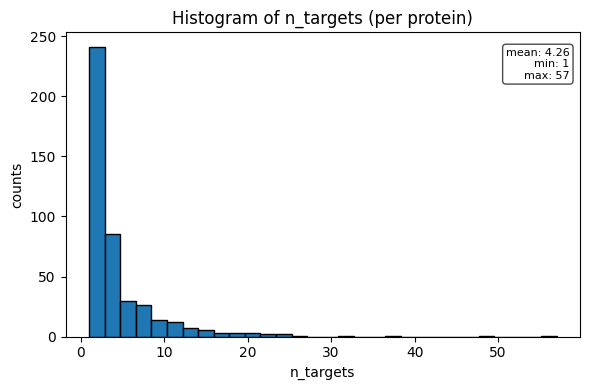

Saved plot: /scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_inputs/counts/plots/n_targets_histogram.png


In [119]:
t_min, t_max = int(plot_df['n_targets'].min()), int(plot_df['n_targets'].max())
fig, ax = plt.subplots(figsize=(6,4))
ax.hist(plot_df['n_targets'], bins=30, color='C0', edgecolor='k')
ax.set_xlabel('n_targets')
ax.set_ylabel('counts')
ax.set_title('Histogram of n_targets (per protein)')
_annotate_stats(ax, plot_df['n_targets'])
fig.tight_layout()
plt.show()
out_path = os.path.join(PLOT_DIR, 'n_targets_histogram.png')
fig.savefig(out_path)
plt.close(fig)
print(f"Saved plot: {out_path}")

### 4-2. n_off_targets distribution histogram

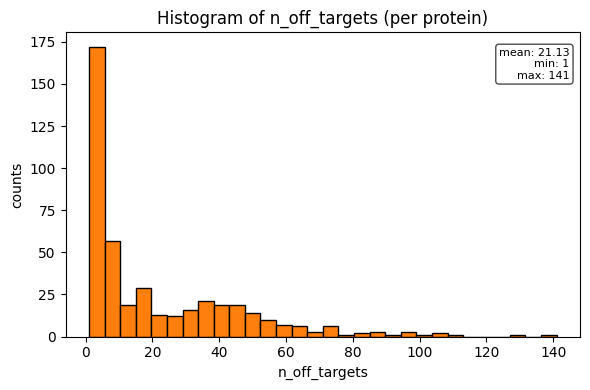

Saved plot: /scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_inputs/counts/plots/n_off_targets_histogram.png


In [120]:
o_min, o_max = int(plot_df['n_off_targets'].min()), int(plot_df['n_off_targets'].max())
fig, ax = plt.subplots(figsize=(6,4))
ax.hist(plot_df['n_off_targets'], bins=30, color='C1', edgecolor='k')
ax.set_xlabel('n_off_targets')
ax.set_ylabel('counts')
ax.set_title('Histogram of n_off_targets (per protein)')
_annotate_stats(ax, plot_df['n_off_targets'])
fig.tight_layout()
plt.show()
out_path = os.path.join(PLOT_DIR, 'n_off_targets_histogram.png')
fig.savefig(out_path)
plt.close(fig)
print(f"Saved plot: {out_path}")

### 4-3. Joint counts bar graph (n_targets x n_off_targets)

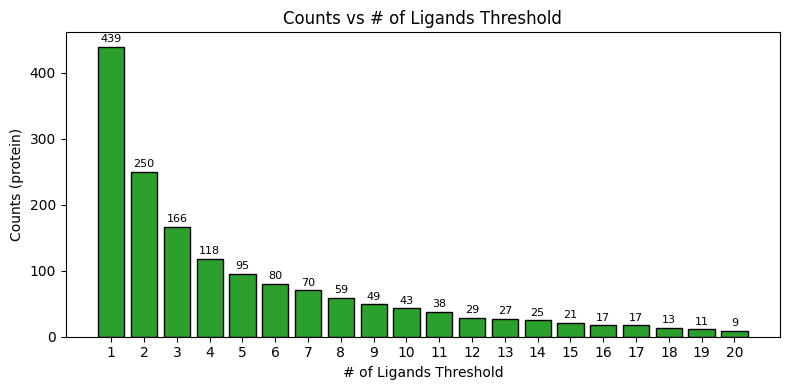

Saved plot: /scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_inputs/counts/plots/counts_vs_threshold_bar.png


In [121]:
max_possible = max(plot_df['n_targets'].max(), plot_df['n_off_targets'].max())
max_k = int(min(20, max_possible)) if max_possible >= 1 else 1
ks = list(range(1, max_k + 1))
counts = [( (plot_df['n_targets'] >= k) & (plot_df['n_off_targets'] >= k) ).sum() for k in ks]

fig, ax = plt.subplots(figsize=(8,4))
ax.bar(ks, counts, color='C2', edgecolor='k')
ax.set_xlabel('# of Ligands Threshold')
ax.set_ylabel('Counts (protein)')
ax.set_title('Counts vs # of Ligands Threshold')
ax.set_xticks(ks)

# annotate bar values
for x, y in zip(ks, counts):
    ax.text(x, y + max(1, int(0.01 * len(plot_df))), str(int(y)), ha='center', va='bottom', fontsize=8)
fig.tight_layout()
plt.show()
out_path = os.path.join(PLOT_DIR, 'counts_vs_threshold_bar.png')
fig.savefig(out_path)
plt.close(fig)
print(f"Saved plot: {out_path}")